## LED Flicker Model Analysis
We modeled radiant exposure (irradiance per unit area integrated over time) as $$\phi(A, D, t_p, t_o, t_s, t_e)$$. The variables are described in the section "Analytical Flicker Model."

In a nutshell, when imaging an LED with a camera, the following parameters are vital: 
1. LED Params: duty cycle ($D$), PWM frequency ($fp$) (we'll assume LED intensity is zero in its OFF phase for now, this can very well be changed; see the flicker model input args).
2. Camera Params: exposure time (te), frame rate
3. Random variable: offset time between exposure start and LED pulse phase. 

The goal of this jupyter notebook is to analyse the model and understand flicker behaviour through experiments on each parameter. 

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact, FloatSlider, IntSlider, Dropdown
import ipywidgets as widgets
import flicker_model as model
from mpl_toolkits.axes_grid1 import make_axes_locatable

In [3]:
def interactive_plot(D, fp, ts, te, frame_rate, Nsec, A=1, offset=0):
    tp = 1000 / fp

    # Ensure ts and te are within valid bounds
    ts = min(ts, tp)
    time, phi_t = model.phi_over_frames(D, fp, te, ts, frame_rate, Nsec, A, offset)
    plt.figure(figsize=(8, 3))
    plt.plot(time, phi_t, lw=2, label='phi', marker='o', markersize=5)
    plt.legend()
    plt.title(f"φ[n] over {Nsec * frame_rate} frames — f_led={fp}, ts={ts:.2f}, te={te:.2f}, D={D:.2f}, fr={frame_rate}")
    plt.xlabel("Time (s)")
    plt.ylabel("Radiant exposure φ[n]")
    plt.grid(True)
    plt.show()

### Validation
Let's reproduce Figures 4, 6, 7, and 8 from the EI 2021 paper "An analytic-numerical image flicker study to test novel flicker
metrics" by Wittpahl et al.

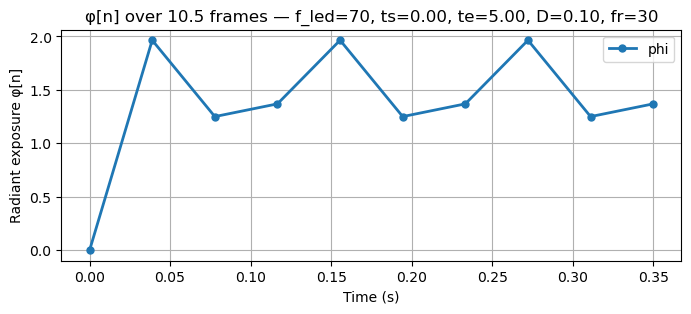

In [4]:
# Reproduce Fig. 4 from EI 2021 paper on flicker analysis (Wittpahl)
interactive_plot(D=0.10, fp=70, ts=0, te=5, frame_rate=30, Nsec=0.35, A=0.5, offset=0.25)

In our model, at time t=0, the camera has just started. The first frame exposure ends in 5 ms and the frame is ready at 33.33 ms (frame rate = 30 fps). With this index shift in mind, this result matches the paper figure exactly.

In another experiment, we reproduce Fig. 6 from the same paper (below code block), with one frame offset. This validates the flicker model in one way. 

We also validated it with controlled lightbox experiments at Omnivision Technologies. 

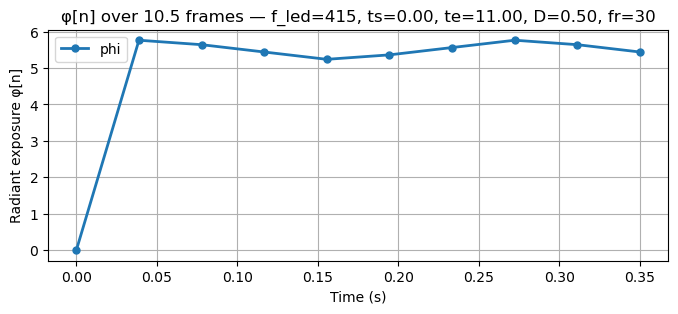

In [5]:
# Fig. 6 from EI 2021 Wittpahl
interactive_plot(D=0.50, fp=415, ts=0, te=11, frame_rate=30, Nsec=0.35, A=0.5, offset=0.25)

In [ ]:
interact(
    interactive_plot,
    D=FloatSlider(min=0, max=1, step=0.05, value=0.25, description="D"),
    fp=FloatSlider(min=90, max=110, step=0.2, value=90, description="fp"),
    ts=FloatSlider(min=0, max=11, step=0.1, value=0, description="ts in [0, tp]"),  
    te=FloatSlider(min=0, max=22, step=0.1, value=1, description="te in [0, 2tp]"),  
    frame_rate=Dropdown(options=[30, 50, 60, 90, 120], value=60, description="fps"),
    Nsec=IntSlider(min=1, max=10, step=1, value=2, description="feed time")
)

interactive(children=(FloatSlider(value=0.25, description='D', max=1.0, step=0.05), FloatSlider(value=90.0, de…

<function __main__.interactive_plot(D, fp, ts, te, frame_rate, Nsec, A=1, offset=0)>

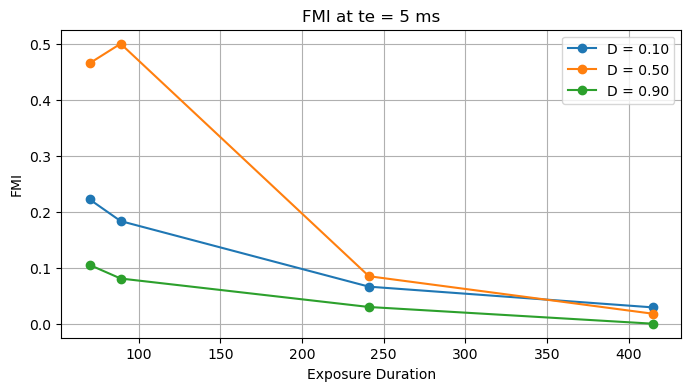

In [7]:
# Fig. 7 from EI2021 Wittpahl
f_led_vals = [70, 89, 241, 415]
d_vals = [0.10, 0.50, 0.90]

plt.figure(figsize=(8, 4))
for d in d_vals:
    perc_flicker_arr = []
    for f_led in f_led_vals:
        tp = 1000 / f_led
        # for given ts and te
        time, phi_t = model.phi_over_frames(D=d, fp=f_led, te=5, ts=0, frame_rate=30, Nsec=1, A=0.5, offset=0.25)

        # now calculate percent flicker
        max_int = np.max(phi_t[1:])  # max intensity 
        min_int = np.min(phi_t[1:])  # the first phi(0) is zero always, leave it
    
        if (max_int + min_int == 0):
            percent_flicker = 0  # no light detected at all, happens in te < to
        else:
            percent_flicker = (max_int - min_int) / (max_int + min_int)

        perc_flicker_arr.append(percent_flicker)

    # min_idx = np.argmin(perc_flicker_arr)
    # te_min = te_vals[min_idx]
    # perc_flicker_min = perc_flicker_arr[min_idx]
    # print("f = {:.1f} Hz: Minimum flicker ({:.2f}%) at te = {:.2f}".format(f_led, perc_flicker_min, te_min))
    plt.plot(f_led_vals, perc_flicker_arr, marker='o', label='D = {:.2f}'.format(d))

plt.title("FMI at te = 5 ms")
plt.ylabel("FMI")
plt.xlabel("Exposure Duration")
plt.grid(True)
plt.legend()
plt.show()

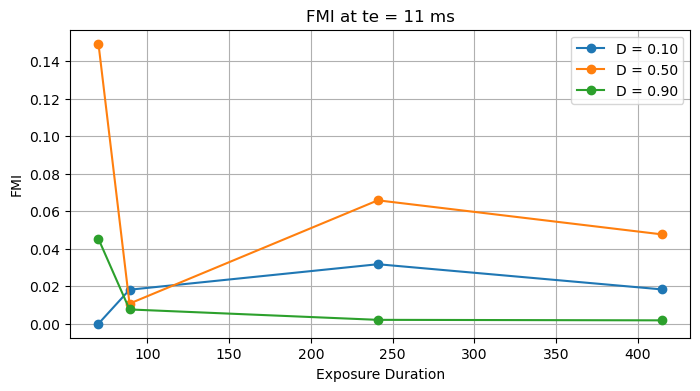

In [8]:
# Fig. 8 from EI2021 Wittpahl
f_led_vals = [70, 89, 241, 415]
d_vals = [0.10, 0.50, 0.90]

plt.figure(figsize=(8, 4))
for d in d_vals:
    perc_flicker_arr = []
    for f_led in f_led_vals:
        tp = 1000 / f_led
        # for given ts and te
        time, phi_t = model.phi_over_frames(D=d, fp=f_led, te=11, ts=0, frame_rate=30, Nsec=1, A=0.5, offset=0.25)

        # now calculate percent flicker
        max_int = np.max(phi_t[1:])  # max intensity 
        min_int = np.min(phi_t[1:])  # the first phi(0) is zero always, leave it
    
        if (max_int + min_int == 0):
            percent_flicker = 0  # no light detected at all, happens in te < to
        else:
            percent_flicker = (max_int - min_int) / (max_int + min_int)

        perc_flicker_arr.append(percent_flicker)

    # min_idx = np.argmin(perc_flicker_arr)
    # te_min = te_vals[min_idx]
    # perc_flicker_min = perc_flicker_arr[min_idx]
    # print("f = {:.1f} Hz: Minimum flicker ({:.2f}%) at te = {:.2f}".format(f_led, perc_flicker_min, te_min))
    plt.plot(f_led_vals, perc_flicker_arr, marker='o', label='D = {:.2f}'.format(d))

plt.title("FMI at te = 11 ms")
plt.ylabel("FMI")
plt.xlabel("Exposure Duration")
plt.grid(True)
plt.legend()
plt.show()

Below is the code to produce Figure 3 in our paper. 

/var/folders/4g/ny1jgc0546v69pmt66_qt03w0000gn/T/ipykernel_73290/3128436999.py:64: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.03, 1, 0.97])


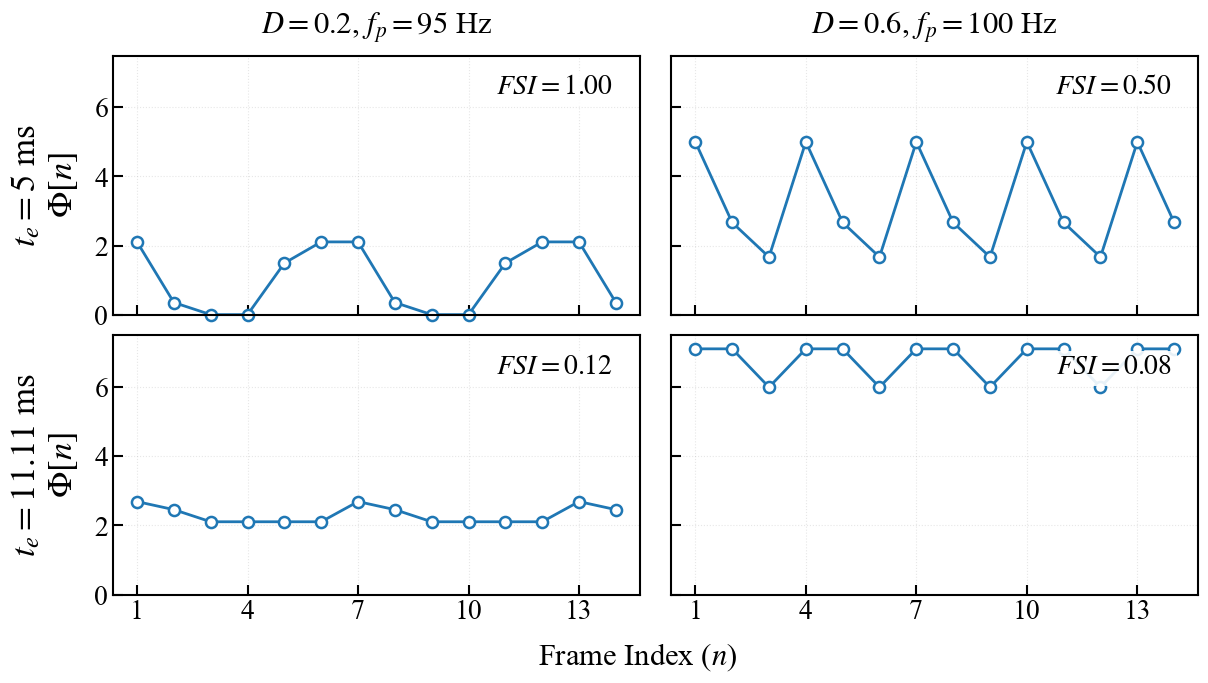

In [9]:
# Journal Quality Configuration: Extra Large for Readability
plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman"],
    "mathtext.fontset": "stix",
    "axes.labelsize": 18,        
    "font.size": 16,              
    "axes.linewidth": 1.5,       
    "xtick.labelsize": 16,       
    "ytick.labelsize": 16,       
    "axes.grid": True,
    "grid.alpha": 0.3,
    "grid.linestyle": ":"
})

def generate_compact_publication_plot(led_params, exp_times, frame_rate=30, Nsec=0.5):
    # Reduced height from 10 to 7 to make subplots more compact
    fig, axes = plt.subplots(len(exp_times), len(led_params), 
                             figsize=(14, 7), sharex=True, sharey='row',
                             gridspec_kw={'hspace': 0.08, 'wspace': 0.06})
    
    A, offset, ts = 1, 0, 0 
    line_color = '#1f77b4' 

    for row, te in enumerate(exp_times):
        for col, (D, fp) in enumerate(led_params):
            ax = axes[row, col]
            
            # Data generation
            _, phi_t_full = model.phi_over_frames(D, fp, te, ts, frame_rate, Nsec, A, offset)
            phi_t = phi_t_full[1:]
            frame_indices = np.arange(1, len(phi_t) + 1)
            
            # Metric calculation
            m_index = (np.max(phi_t) - np.min(phi_t)) / (np.max(phi_t) + np.min(phi_t))
            
            # Plot
            ax.plot(frame_indices, phi_t, marker='o', markersize=8, 
                    markerfacecolor='white', markeredgewidth=1.8,
                    linestyle='-', linewidth=2.0, color=line_color, clip_on=False)
            
            # common y-range
            ax.set_ylim(0, 7.5)
            
            # Row and Column Labels
            if row == 0:
                ax.set_title(f"$D = {D}$, $f_p = {fp}$ Hz", pad=15, fontsize=22)
            
            if col == 0:
                ax.set_ylabel(f"$t_e = {te}$ ms\n$\Phi[n]$", fontsize=25, labelpad=10)

            # Modulation Index Annotation
            ax.text(0.95, 0.92, f"$FSI = {m_index:.2f}$", transform=ax.transAxes, 
                    ha='right', va='top', fontsize=20, fontweight='bold',
                    bbox=dict(facecolor='white', alpha=0.9, edgecolor='none'))
            
            ax.set_xticks([1, 4, 7, 10, 13])
            ax.tick_params(direction='in', length=7, width=1.5, labelsize=20)

    # Positioned X-axis label closer to the plot
    fig.text(0.5, 0.01, 'Frame Index ($n$)', ha='center', fontsize=22)
    
    # tight_layout with minimized padding for a cleaner export
    plt.tight_layout(rect=[0, 0.03, 1, 0.97])
    
    # Save command for your paper
    # plt.savefig("flicker_comparison_compact.pdf", bbox_inches='tight', dpi=300)
    plt.show()

led_params = [(0.2, 95), (0.6, 100)]
# led_params = [(0.2, 95)]
exp_times = [5, 11.11]

generate_compact_publication_plot(led_params, exp_times)

### Further Analysis: Percent Flicker
Now we analyse percent flicker with the goal to find the set of parameters that minimize flicker. 

D = 0.10: Minimum flicker (0.10%) at te = 11.10
D = 0.15: Minimum flicker (0.10%) at te = 11.10
D = 0.20: Minimum flicker (0.10%) at te = 11.10
D = 0.25: Minimum flicker (0.10%) at te = 11.10
D = 0.40: Minimum flicker (0.10%) at te = 11.10
D = 0.50: Minimum flicker (0.10%) at te = 11.10
D = 0.75: Minimum flicker (0.03%) at te = 11.10


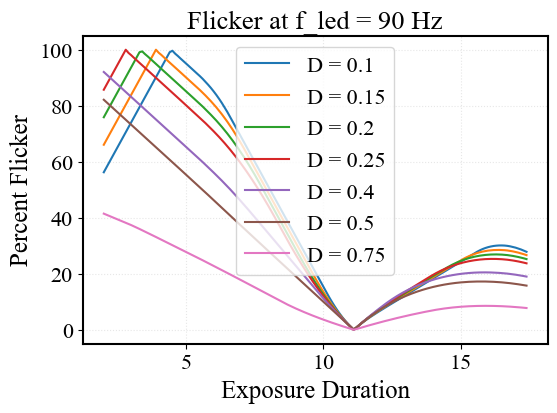

In [10]:
f_led = 90
tp = 1000 / f_led
D_vals = [0.1, 0.15, 0.2, 0.25, 0.4, 0.5, 0.75]
ts_vals = np.arange(0, tp, 0.1)
te_max = 17.5
te_vals = np.arange(2, te_max, 0.1)

plt.figure(figsize=(6, 4))
for d in D_vals:
    perc_flicker_arr = []
    for te in te_vals:
        perc_flicker_te = []
        for ts in ts_vals:  # we want to average over ts
            # for given ts and te
            time, phi_t_ts = model.phi_over_frames(D=d, fp=f_led, te=te, ts=ts, frame_rate=60, Nsec=1)

            # now calculate percent flicker
            max_int = np.max(phi_t_ts[1:])  # max intensity 
            min_int = np.min(phi_t_ts[1:])  # the first phi(0) is zero always, leave it
        
            if (max_int + min_int == 0):
                percent_flicker = 0  # no light detected at all, happens in te < to
            else:
                percent_flicker = (max_int - min_int) * 100 / (max_int + min_int)

            perc_flicker_te.append(percent_flicker)
        perc_flicker_arr.append(np.mean(perc_flicker_te))

    min_idx = np.argmin(perc_flicker_arr)
    te_min = te_vals[min_idx]
    perc_flicker_min = perc_flicker_arr[min_idx]
    print("D = {:.2f}: Minimum flicker ({:.2f}%) at te = {:.2f}".format(d, perc_flicker_min, te_min))
    plt.plot(te_vals, perc_flicker_arr, label='D = {}'.format(d))

plt.title("Flicker at f_led = {} Hz".format(f_led))
plt.ylabel("Percent Flicker")
plt.xlabel("Exposure Duration")
plt.grid(True)
plt.legend()
plt.show()

For the given PWM frequency and camera fps, 11.11 ms exposure results in zero flicker for all duty cycles. 

f = 88.0 Hz: Minimum flicker (0.64%) at te = 11.40
f = 88.8 Hz: Minimum flicker (0.68%) at te = 11.30
f = 89.2 Hz: Minimum flicker (0.19%) at te = 11.20
f = 89.8 Hz: Minimum flicker (0.56%) at te = 11.10
f = 90.0 Hz: Minimum flicker (0.10%) at te = 11.10
f = 90.2 Hz: Minimum flicker (0.21%) at te = 11.10
f = 90.4 Hz: Minimum flicker (0.68%) at te = 11.10
f = 91.0 Hz: Minimum flicker (0.20%) at te = 11.00
f = 92.0 Hz: Minimum flicker (0.56%) at te = 10.90


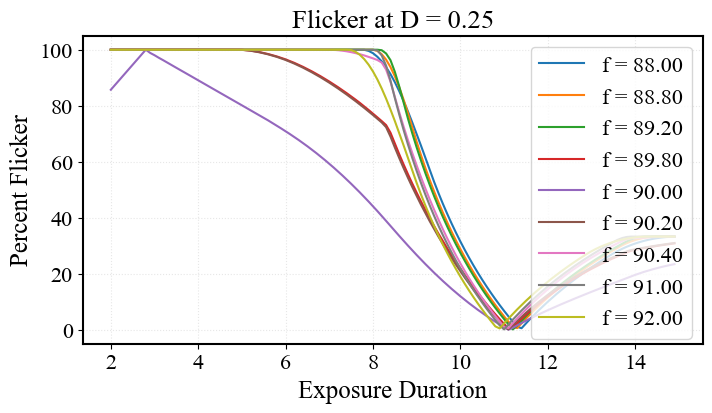

In [11]:
f_led_vals = [88, 88.8, 89.2, 89.8, 90, 90.2, 90.4, 91, 92]
d = 0.25
te_max = 15
te_vals = np.arange(2, te_max, 0.1)

plt.figure(figsize=(8, 4))
for f_led in f_led_vals:
    perc_flicker_arr = []
    tp = 1000 / f_led
    ts_vals = np.arange(0, tp, 0.1)
    for te in te_vals:
        perc_flicker_te = []
        for ts in ts_vals:  # we want to average over ts
            # for given ts and te
            time, phi_t_ts = model.phi_over_frames(D=d, fp=f_led, te=te, ts=ts, frame_rate=60, Nsec=1)

            # now calculate percent flicker
            max_int = np.max(phi_t_ts[1:])  # max intensity 
            min_int = np.min(phi_t_ts[1:])  # the first phi(0) is zero always, leave it
        
            if (max_int + min_int == 0):
                percent_flicker = 0  # no light detected at all, happens in te < to
            else:
                percent_flicker = (max_int - min_int) * 100 / (max_int + min_int)

            perc_flicker_te.append(percent_flicker)
        perc_flicker_arr.append(np.mean(perc_flicker_te))

    min_idx = np.argmin(perc_flicker_arr)
    te_min = te_vals[min_idx]
    perc_flicker_min = perc_flicker_arr[min_idx]
    print("f = {:.1f} Hz: Minimum flicker ({:.2f}%) at te = {:.2f}".format(f_led, perc_flicker_min, te_min))
    plt.plot(te_vals, perc_flicker_arr, label='f = {:.2f}'.format(f_led))

plt.title("Flicker at D = {:.2f}".format(d))
plt.ylabel("Percent Flicker")
plt.xlabel("Exposure Duration")
plt.grid(True)
plt.legend()
plt.show()

Even on varying PWM frequency, flicker is minimized at around 11.11 exposure. 

### Rolling Shutter Simulation
Here we use the flicker model over rows of a rolling shutter sensor. Specifically, we simulate imaging an area light -- a lightbox which is a single LED (the whole lightbox screen is synchronized). This would mean that radiant intensity over its spatial extent is PWM modulated. We image it with a rolling shutter of line time 10 usecs. 

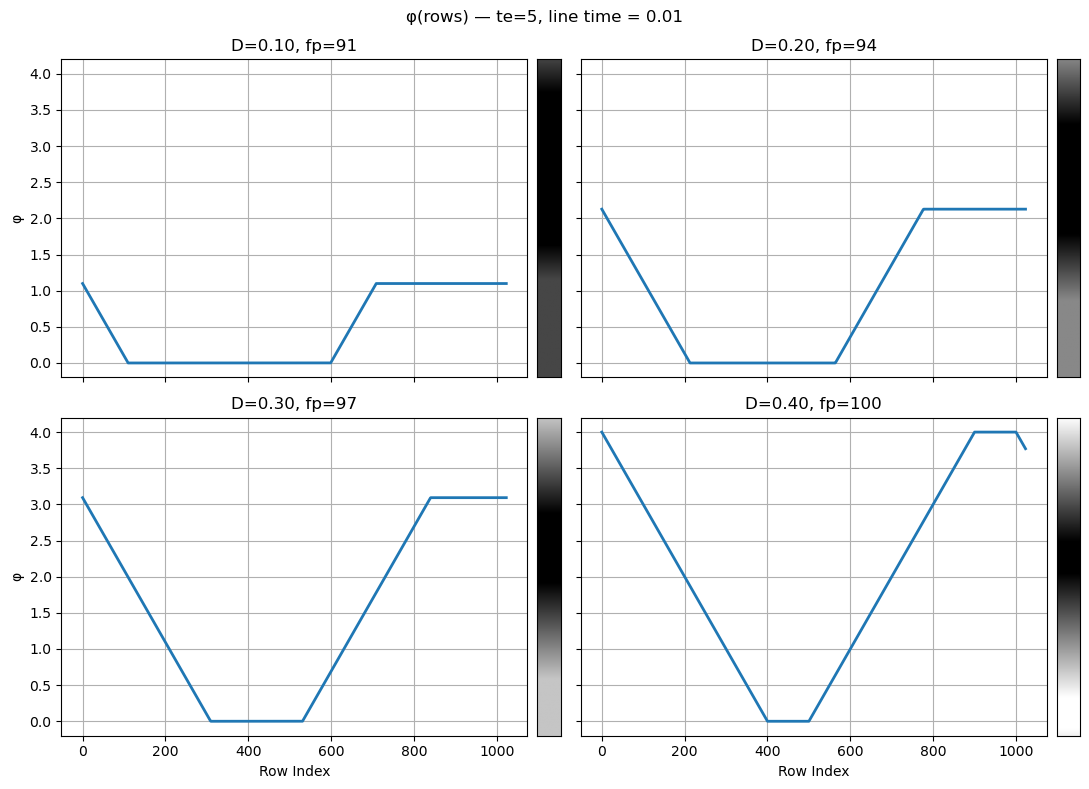

In [2]:
Nrows = 1024  # Number of rolling shutter rows
td = 0.01   # Line time of RS in microseconds
te = 5  # Exposure time in ms
ts_init = 0  # Offset time for the first row in ms

# We'll repeat the experiment for four different LEDs
d_fp_pairs = [(0.1, 91), (0.2, 94), (0.3, 97), (0.4, 100)]  # (D, fp)

def plot_rs(d_fp_pairs):
    fig, axes = plt.subplots(2, 2, figsize=(11, 8), sharex=True, sharey=True)

    for i, (D, fp) in enumerate(d_fp_pairs):
        r, c = divmod(i, 2)
        ax = axes[r, c]

        row_capture = model.phi_over_rows(D, fp, te, ts_init, td, Nrows, A=1, offset=0)
            
        ax.plot(np.arange(Nrows), row_capture, lw=2)
        ax.set_title(f"D={D:.2f}, fp={fp}")
        ax.grid(True)
        if r == 1:
            ax.set_xlabel("Row Index")
        if c == 0:
            ax.set_ylabel("φ")
        
        divider = make_axes_locatable(ax)
        ax_img = divider.append_axes("right", size="5%", pad=0.1)  

        # draw grayscale strip showing RS banding
        ax_img.imshow(
            row_capture[:, None],
            cmap="gray", aspect="auto",
            vmin=0, vmax=4
        )

        # remove ticks/labels so it looks like a clean column
        ax_img.set_xticks([])
        ax_img.set_yticks([])

    fig.suptitle(f"φ(rows) — te={te}, line time = {td}", y=0.98)
    fig.tight_layout()
    plt.show()         

plot_rs(d_fp_pairs)

The vertical band on the right illustrates the rolling shutter image. 